In [1]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Ridge
from xgboost import XGBClassifier, XGBRegressor


import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
""" phase1DF = pd.read_csv(r'FinalData\phase1.csv')
phase2DF = pd.read_csv(r'FinalData\phase2.csv')
phase3DF = pd.read_csv(r'FinalData\phase3.csv')
preOpDataDF = pd.read_csv(r'FinalData\PreOp.csv') """
allData = pd.read_csv(r'FinalData\euroSCOREII.csv')
outComesDF = pd.read_csv(r'FinalData\OutComes.csv')


""" phase1DF.columns = [phase1DF.columns[0]] + ['P1_' + col for col in phase1DF.columns[1:]]
phase2DF.columns = [phase2DF.columns[0]] + ['P2_' + col for col in phase2DF.columns[1:]]
phase3DF.columns = [phase3DF.columns[0]] + ['P3_' + col for col in phase3DF.columns[1:-9]] + list(phase3DF.columns[-9:]) """

""" allData = pd.merge(preOpDataDF, phase1DF , on = 'CPR' , how = 'left')
allData = pd.merge(allData, phase2DF , on = 'CPR' , how = 'left')
allData = pd.merge(allData, phase3DF , on = 'CPR' , how = 'left') """
allData = allData.drop(columns = ['EuroScoreII_1', 'EuroScoreII_2'])
allData = allData[allData['EuroScoreII'].notna()].reset_index(drop = True)
allData

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\CLUN0185\AppData\Local\Temp\ipykernel_12684\2531422813.py:1: SyntaxWarning: invalid escape sequence '\p'
  """ phase1DF = pd.read_csv(r'FinalData\phase1.csv')


,CPR,EuroScoreII
0,0,4.20
1,2,1.67
2,3,4.56
3,4,0.84
4,5,0.96
...,...,...
2121,3870,0.63
2122,3875,3.79
2123,3881,1.92
2124,3885,0.97


In [3]:
outComesDF['within90Days'].value_counts()

within90Days
0    3761
1     128
Name: count, dtype: int64

In [4]:
outComesDF = outComesDF[outComesDF['CPR'].isin(allData['CPR'])]
outComesDF['within90Days'].value_counts()

within90Days
0    2059
1      67
Name: count, dtype: int64

Define Folds, features and outcomes

In [5]:
outerFolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
innerFolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

X = allData.drop(columns = 'CPR')
y = outComesDF['within90Days']

Define training algorithm

In [6]:
def trainModel(model, paramGrid, X, phase, type) :
    outerPR = []
    outerROC = []
    outerPRAUC = []
    mean_recall = np.linspace(0, 1, 100)
    precisions = []
    pr_aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    colors = sns.color_palette("colorblind", n_colors=5)

    plt.figure(figsize=(16, 6))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    rocAx = axes[0]
    prAx = axes[1]
    foldCount = 1

    for train, test in outerFolds.split(X,y) :
        
        Xtrain, Xtest = X.iloc[train], X.iloc[test]
        yTrain, yTest = y.iloc[train], y.iloc[test]

        gridSearch = GridSearchCV(model, paramGrid, cv=innerFolds, 
                                            verbose=4, 
                                            scoring='roc_auc', 
                                            return_train_score=True, 
                                            n_jobs=-1)
        gridSearch.fit(Xtrain, yTrain)

        bestModel = gridSearch.best_estimator_

        results = gridSearch.cv_results_
        bestModel = gridSearch.best_estimator_
        bestParams = gridSearch.best_params_

        # Evaluate the model on the holdout set
        yScores = bestModel.predict_proba(Xtest)[:,1]

        fpr, tpr, _ = roc_curve(yTest, yScores)
        rocAuc = auc(fpr, tpr)
        
        aucs.append(rocAuc)

        # Interpolate to the common mean_fpr grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        
        rocAx.plot(fpr, tpr, lw=2, color=colors[foldCount - 1], label=f'ROC Fold {foldCount} (area = {rocAuc:.2f})')

        precision, recall, _ = precision_recall_curve(yTest, yScores)
        prAuc = auc(recall, precision)
        pr_aucs.append(prAuc)

        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])  # reverse needed due to decreasing recall
        precisions.append(interp_precision)

        prAx.plot(recall, precision, lw=2, color=colors[foldCount - 1], label=f'PR Fold {foldCount} (area = {prAuc:.2f})')

        foldCount+=1

        # Calculate metrics
        holdoutPR = prAuc * 100
        holdoutAUC = roc_auc_score(yTest, yScores) * 100  # Use probabilities for AUC

        outerPR.append(holdoutPR)
        outerROC.append(holdoutAUC)

        # Print the summary
        print(f"Best parameters: {bestParams}")
        print(f"Holdout Set PR AUC: {holdoutPR:.2f}%")
        print(f"Holdout Set ROC AUC: {holdoutAUC:.2f}%")


    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)    
    rocAx.plot(mean_fpr, mean_tpr, color='navy', linestyle='-', linewidth=3,
               label=f'Mean ROC (area = {mean_auc:.2f})')
    rocAx.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                       color='navy', alpha=0.2, label=r'$\pm$ 1 std. dev.')   
    rocAx.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    rocAx.set_xlim([0.0, 1.0])
    rocAx.set_ylim([0.0, 1.05])
    rocAx.set_xlabel('False Positive Rate')
    rocAx.set_ylabel('True Positive Rate')
    rocAx.set_title('Receiver Operating Characteristic (ROC) of ' + type + ' in phase %d' % phase)
    rocAx.legend(loc="lower right")
    rocAx.grid(alpha=0.3)

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)

    prAx.plot(mean_recall, mean_precision, color='darkorange', linestyle='-', linewidth=3,
              label=f'Mean PR (area = {mean_pr_auc:.2f})')
    prAx.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision,
                      color='orange', alpha=0.2, label=r'$\pm$ 1 std. dev.')
    prAx.set_xlim([0.0, 1.0])
    prAx.set_ylim([0.0, 1.05])
    prAx.set_xlabel('Recall')
    prAx.set_ylabel('Precision')
    prAx.set_title('Precision-Recall (PR) Curve of ' + type + ' in phase %d' % phase)
    prAx.legend(loc="upper right")
    prAx.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return outerPR, outerROC



### Regression

In [7]:
C_parameter = np.logspace(-5, 5, 20)
model = LogisticRegression()

paramGrid = {
    'penalty' : ['l2'],
    'C' : C_parameter,
    'solver' : ['lbfgs'],
    'max_iter' : [10000],
    'class_weight'  : [None]
    }

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(1e-05), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 3.92%
Holdout Set ROC AUC: 58.71%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(1e-05), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 3.39%
Holdout Set ROC AUC: 52.22%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(1e-05), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 3.96%
Holdout Set ROC AUC: 59.25%
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': np.float64(1e-05), 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'lbfgs'}
Holdout Set PR AUC: 3.96%
Holdout Set ROC AUC: 51.55%
Fitting 5 folds for each of 20 candidates, totalling 100 fit

<Figure size 1600x600 with 0 Axes>

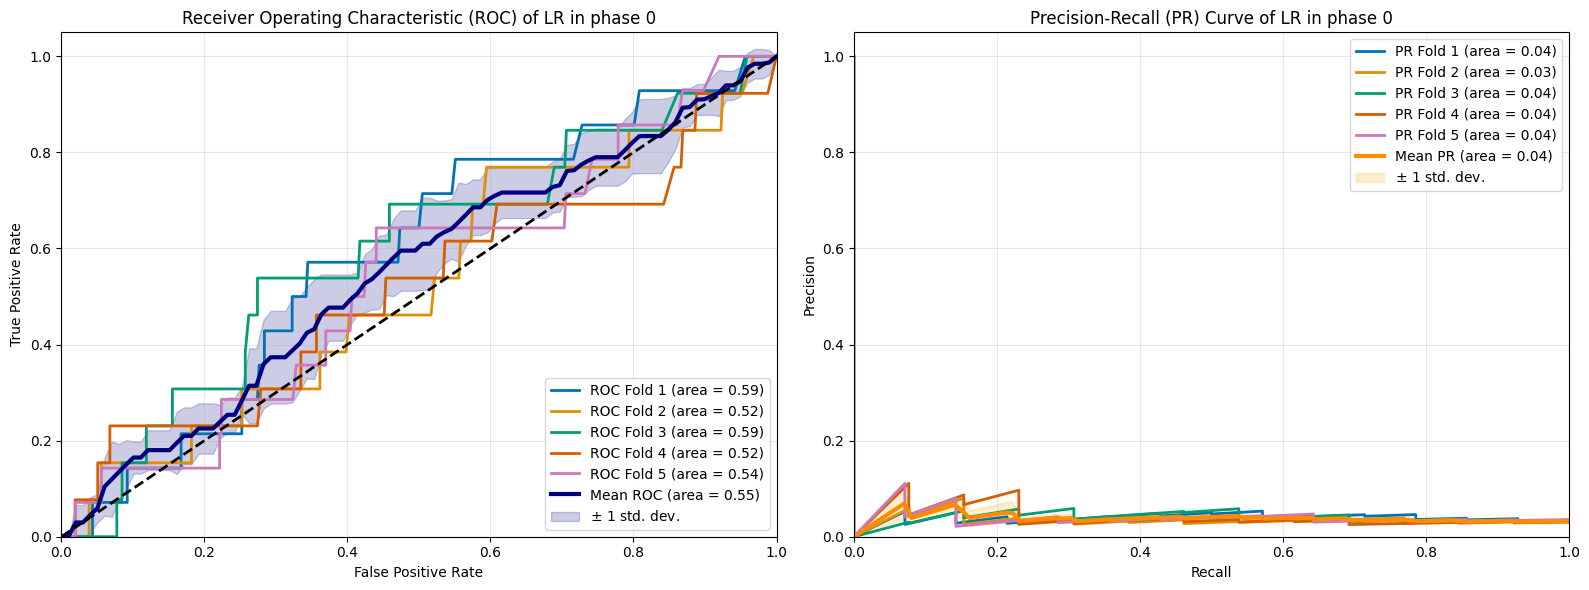

In [8]:
outerPR, outerROC = trainModel(model, paramGrid, X , phase=0, type="LR")

In [9]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 3.8180 
 standard deviation: 0.2172 
 standard error of mean: 0.0971
Nested CV ROC: 
 mean: 55.0890 
 standard deviation: 3.2588 
 standard error of mean: 1.4574


In [10]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_reg_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_reg_death.fit(Xtrain, yTrain)

    bestModel = grid_search_reg_death.best_estimator_



    results_reg_death = grid_search_reg_death.cv_results_
    best_model_reg_death = grid_search_reg_death.best_estimator_
    best_params_reg_death = grid_search_reg_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_reg_death = best_model_reg_death.predict_proba(Xtest)[:,1]

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(yTest, y_pred_reg_death)
    roc_auc = auc(fpr, tpr)
    
    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_reg_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    # Calculate metrics
    holdout_pr_reg_death = pr_auc * 100
    holdout_auc_reg_death = roc_auc_score(yTest, y_pred_reg_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_reg_death)
    outerROC.append(holdout_auc_reg_death)

    # Print the summary
    print(f"Best parameters: {best_params_reg_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_reg_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_reg_death:.2f}%")

    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_reg_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_reg_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_reg_death.best_estimator_\n\n\n\n    results_reg_death = grid_search_reg_death.cv_results_\n    best_model_reg_death = grid_search_reg_death.best_estimator_\n    best_params_reg_death = grid_search_reg_death.best_params_\n\n    # Evaluate the model on the holdout set\n    y_pr

### Tree

In [11]:
model = DecisionTreeClassifier(random_state=0)

paramGrid = {
    'criterion': ['entropy'],
    'max_depth': [None, 5, 10, 15, 20],              
    'max_features': [None],  #None
    'class_weight': [None],   #None
}

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'max_features': None}
Holdout Set PR AUC: 2.76%
Holdout Set ROC AUC: 41.36%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'max_features': None}
Holdout Set PR AUC: 2.33%
Holdout Set ROC AUC: 43.47%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None}
Holdout Set PR AUC: 2.93%
Holdout Set ROC AUC: 50.17%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None}
Holdout Set PR AUC: 2.10%
Holdout Set ROC AUC: 45.72%
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_dept

<Figure size 1600x600 with 0 Axes>

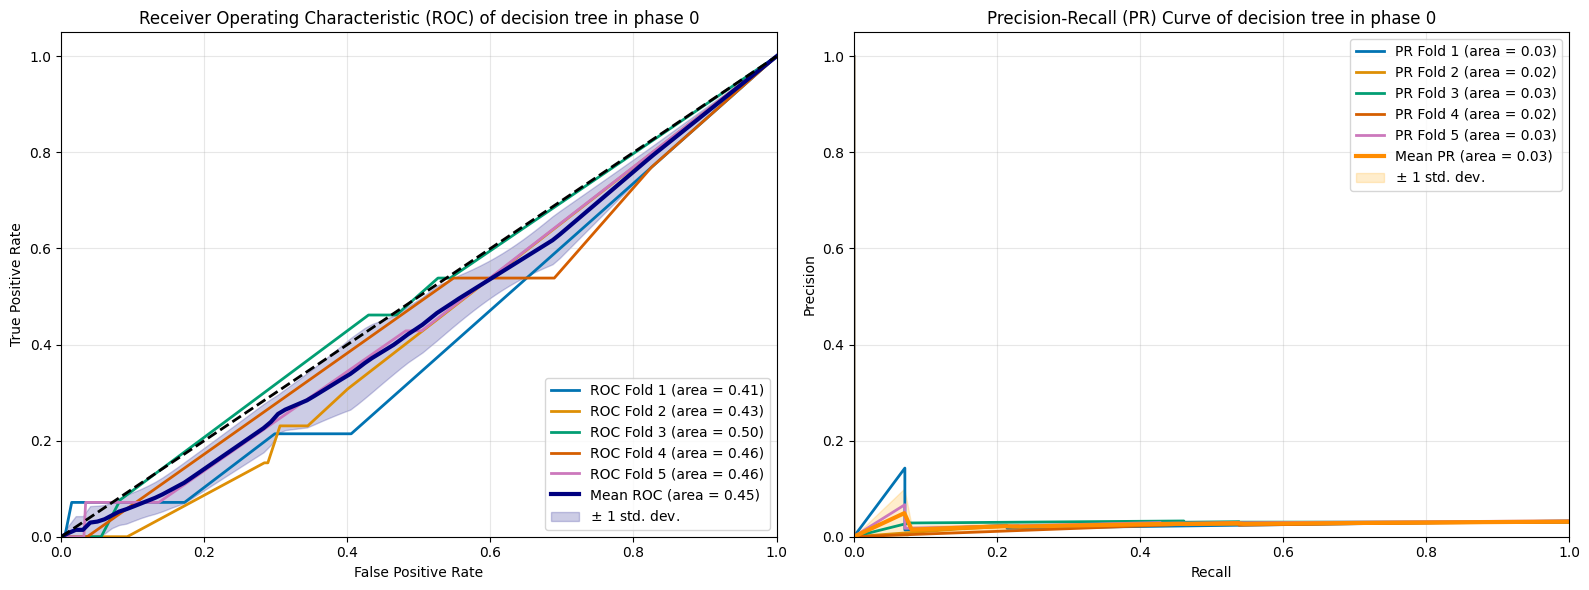

In [12]:
outerPR, outerROC = trainModel(model, paramGrid, X , phase=0, type='decision tree')

In [13]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 2.5895 
 standard deviation: 0.3191 
 standard error of mean: 0.1427
Nested CV ROC: 
 mean: 45.2967 
 standard deviation: 2.9314 
 standard error of mean: 1.3109


In [14]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_tree_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_tree_death.fit(Xtrain, yTrain)

    bestModel = grid_search_tree_death.best_estimator_



    results_tree_death = grid_search_tree_death.cv_results_
    best_model_tree_death = grid_search_tree_death.best_estimator_
    best_params_tree_death = grid_search_tree_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_tree_death = best_model_tree_death.predict_proba(Xtest)[:,1]

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(yTest, y_pred_tree_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_tree_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    # Calculate metrics
    holdout_pr_tree_death = pr_auc * 100
    holdout_auc_tree_death = roc_auc_score(yTest, y_pred_tree_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_tree_death)
    outerROC.append(holdout_auc_tree_death)

    # Print the summary
    print(f"Best parameters: {best_params_tree_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_tree_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_tree_death:.2f}%")

    


    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_tree_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_tree_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_tree_death.best_estimator_\n\n\n\n    results_tree_death = grid_search_tree_death.cv_results_\n    best_model_tree_death = grid_search_tree_death.best_estimator_\n    best_params_tree_death = grid_search_tree_death.best_params_\n\n    # Evaluate the model on the holdout set\

### ANN

In [15]:
model = MLPClassifier(max_iter=1000, random_state=0) #Increase max_iter
C_parameter = np.logspace(-5, 5, 10)
paramGrid = {
    'hidden_layer_sizes': [(2,), (5,), (10,), (2, 2,), (5,5,), (10,), (10,10,)], #potentially not 15 20
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': C_parameter, #Do the same as regression C_parameter
    'learning_rate_init': [0.001, 0.01, 0.1] 
}


Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'tanh', 'alpha': np.float64(599.4842503189421), 'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.1, 'solver': 'adam'}
Holdout Set PR AUC: 2.60%
Holdout Set ROC AUC: 41.40%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'tanh', 'alpha': np.float64(0.0001291549665014884), 'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.1, 'solver': 'adam'}
Holdout Set PR AUC: 3.36%
Holdout Set ROC AUC: 52.24%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'tanh', 'alpha': np.float64(46.41588833612782), 'hidden_layer_sizes': (2, 2), 'learning_rate_init': 0.1, 'solver': 'adam'}
Holdout Set PR AUC: 4.05%
Holdout Set ROC AUC: 61.15%
Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best parameters: {'activation': 'relu', 'alpha': np.float64(7742.636826811277), 'hidden_layer_sizes': (5,), '

<Figure size 1600x600 with 0 Axes>

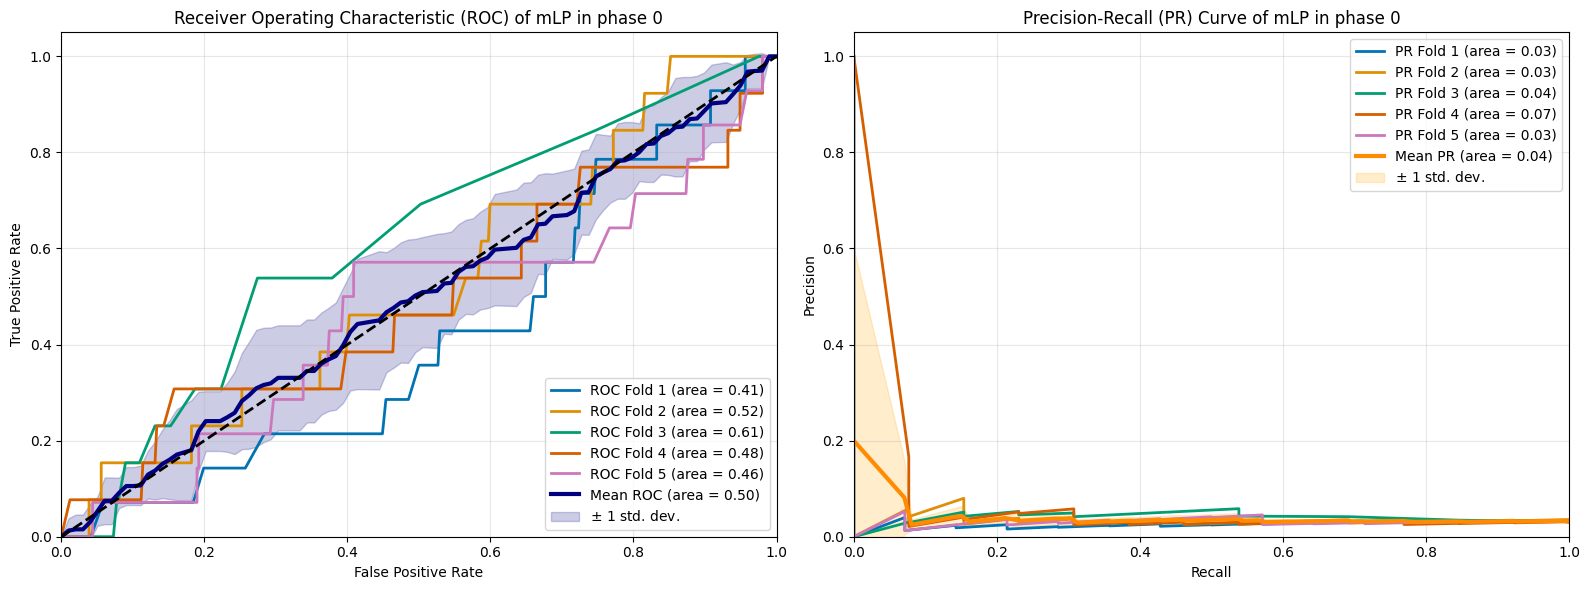

In [16]:
outerPR, outerROC = trainModel(model, paramGrid, X , phase=0, type='mLP')

In [17]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 4.1040 
 standard deviation: 1.7359 
 standard error of mean: 0.7763
Nested CV ROC: 
 mean: 49.9403 
 standard deviation: 6.6045 
 standard error of mean: 2.9536


In [18]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_mlp_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_mlp_death.fit(Xtrain, yTrain)

    bestModel = grid_search_mlp_death.best_estimator_



    results_mlp_death = grid_search_mlp_death.cv_results_
    best_model_mlp_death = grid_search_mlp_death.best_estimator_
    best_params_mlp_death = grid_search_mlp_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_mlp_death = best_model_mlp_death.predict_proba(Xtest)[:,1]

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(yTest, y_pred_mlp_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_mlp_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    # Calculate metrics
    holdout_pr_mlp_death = pr_auc * 100
    holdout_auc_mlp_death = roc_auc_score(yTest, y_pred_mlp_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_mlp_death)
    outerROC.append(holdout_auc_mlp_death)

    # Print the summary
    print(f"Best parameters: {best_params_mlp_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_mlp_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_mlp_death:.2f}%")

    
    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_mlp_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_mlp_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_mlp_death.best_estimator_\n\n\n\n    results_mlp_death = grid_search_mlp_death.cv_results_\n    best_model_mlp_death = grid_search_mlp_death.best_estimator_\n    best_params_mlp_death = grid_search_mlp_death.best_params_\n\n    # Evaluate the model on the holdout set\n    y_pr

### XGBoost

In [19]:
paramGrid = {
    'max_depth': [5, 6, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [50, 100, 200],
    #'scale_pos_weight': [0.75 * scale_pos_weight, scale_pos_weight, 1.25 * scale_pos_weight],
    'reg_alpha': [1],
    'reg_lambda': [1]
}
model = XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=0)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 3.04%
Holdout Set ROC AUC: 44.97%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 2.80%
Holdout Set ROC AUC: 49.18%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 2.20%
Holdout Set ROC AUC: 37.06%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Holdout Set PR AUC: 7.23%
Holdout Set ROC AUC: 50.34%
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.

<Figure size 1600x600 with 0 Axes>

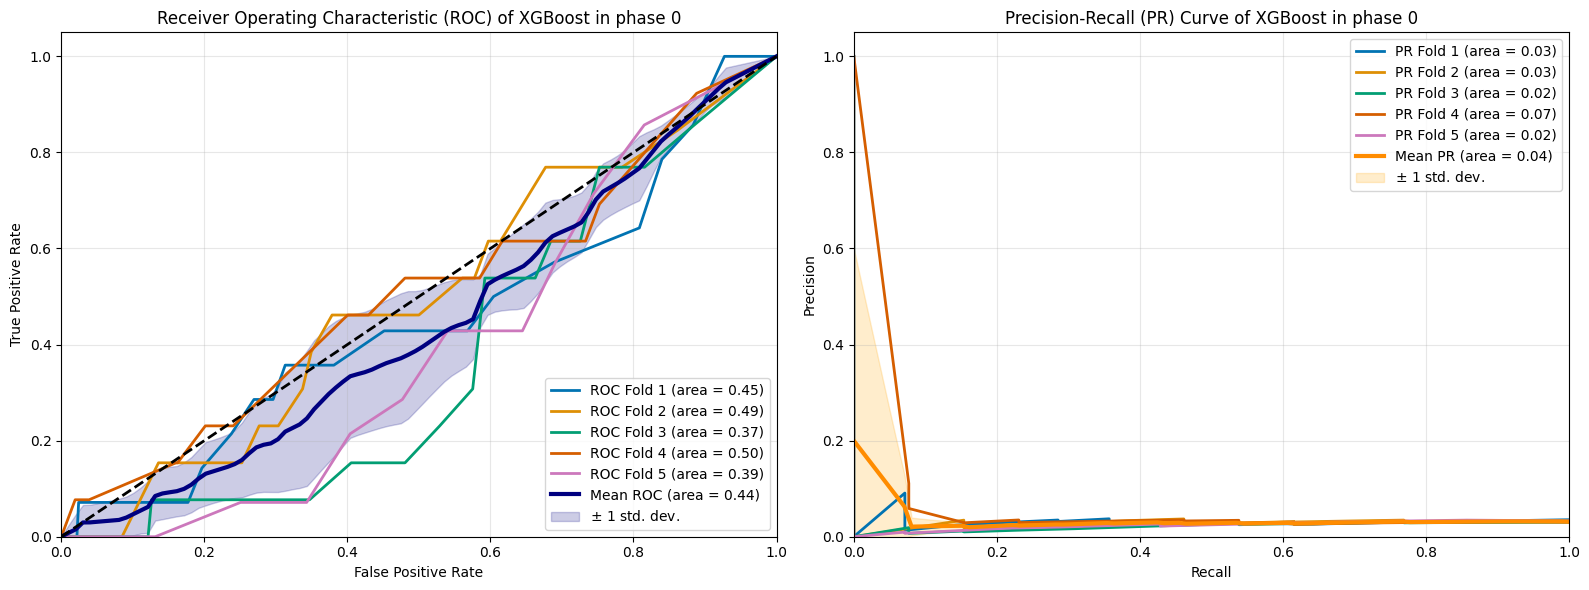

In [20]:
outerPR, outerROC = trainModel(model, paramGrid, X , phase=0, type='XGBoost')

In [21]:
#outerPR.append(holdout_pr_reg_death)
#outerROC.append(holdout_auc_reg_death)

meanPR = np.mean(outerPR)
stdPR = np.std(outerPR)
semPR = stdPR/np.sqrt(len(outerPR))

print(f"Nested CV PR AUC \n mean: {meanPR:.4f} \n standard deviation: {stdPR:.4f} \n standard error of mean: {semPR:.4f}")

meanROC = np.mean(outerROC)
stdROC = np.std(outerROC)
semROC = stdROC/np.sqrt(len(outerROC))

print(f"Nested CV ROC: \n mean: {meanROC:.4f} \n standard deviation: {stdROC:.4f} \n standard error of mean: {semROC:.4f}")

Nested CV PR AUC 
 mean: 3.5323 
 standard deviation: 1.8697 
 standard error of mean: 0.8362
Nested CV ROC: 
 mean: 44.1077 
 standard deviation: 5.3121 
 standard error of mean: 2.3757


In [22]:
""" outerPR = []
outerROC = []
outerPRAUC = []

plt.figure(figsize=(16, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_ax = axes[0]
pr_ax = axes[1]
foldCount = 1

for train, test in outerFolds.split(X,y) :
    
    Xtrain, Xtest = X.iloc[train], X.iloc[test]
    yTrain, yTest = y.iloc[train], y.iloc[test]

    grid_search_XGB_death = GridSearchCV(model, param_grid, cv=innerFolds, 
                                         verbose=4, 
                                         scoring='roc_auc', 
                                         return_train_score=True, 
                                         n_jobs=-1)

    grid_search_XGB_death.fit(Xtrain, yTrain)

    bestModel = grid_search_XGB_death.best_estimator_



    results_XGB_death = grid_search_XGB_death.cv_results_
    best_model_XGB_death = grid_search_XGB_death.best_estimator_
    best_params_XGB_death = grid_search_XGB_death.best_params_

    # Evaluate the model on the holdout set
    y_pred_XGB_death = best_model_XGB_death.predict_proba(Xtest)[:,1]

    fpr, tpr, _ = roc_curve(yTest, y_pred_XGB_death)
    roc_auc = auc(fpr, tpr)

    roc_ax.plot(fpr, tpr, lw=2, label=f'ROC Fold {foldCount} (area = {roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(yTest, y_pred_XGB_death)
    pr_auc = auc(recall, precision)
    outerPRAUC.append(pr_auc)
    pr_ax.plot(recall, precision, lw=2-foldCount/10, label=f'PR Fold {foldCount} (area = {pr_auc:.2f})')

    foldCount+=1

    #y_pred_binary_reg_death = (y_pred_reg_death >= threshold).astype(int)
    #y_test_binary_ = (y_test_std['within90Days'] >= threshold).astype(int)

    # Calculate metrics
    holdout_pr_XGB_death = pr_auc * 100
    holdout_auc_XGB_death = roc_auc_score(yTest, y_pred_XGB_death) * 100  # Use probabilities for AUC

    outerPR.append(holdout_pr_XGB_death)
    outerROC.append(holdout_auc_XGB_death)

    # Print the summary
    print(f"Best parameters: {best_params_XGB_death}")
    print(f"Holdout Set PR AUC: {holdout_pr_XGB_death:.2f}%")
    print(f"Holdout Set ROC AUC: {holdout_auc_XGB_death:.2f}%")

    


    
roc_ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
roc_ax.set_xlim([0.0, 1.0])
roc_ax.set_ylim([0.0, 1.05])
roc_ax.set_xlabel('False Positive Rate')
roc_ax.set_ylabel('True Positive Rate')
roc_ax.set_title('Receiver Operating Characteristic (ROC)')
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.3)

pr_ax.set_xlim([0.0, 1.0])
pr_ax.set_ylim([0.0, 1.05])
pr_ax.set_xlabel('Recall')
pr_ax.set_ylabel('Precision')
pr_ax.set_title('Precision-Recall Curve')
pr_ax.legend(loc="lower right")
pr_ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
 """

' outerPR = []\nouterROC = []\nouterPRAUC = []\n\nplt.figure(figsize=(16, 6))\n\nfig, axes = plt.subplots(1, 2, figsize=(16, 6))\nroc_ax = axes[0]\npr_ax = axes[1]\nfoldCount = 1\n\nfor train, test in outerFolds.split(X,y) :\n\n    Xtrain, Xtest = X.iloc[train], X.iloc[test]\n    yTrain, yTest = y.iloc[train], y.iloc[test]\n\n    grid_search_XGB_death = GridSearchCV(model, param_grid, cv=innerFolds, \n                                         verbose=4, \n                                         scoring=\'roc_auc\', \n                                         return_train_score=True, \n                                         n_jobs=-1)\n\n    grid_search_XGB_death.fit(Xtrain, yTrain)\n\n    bestModel = grid_search_XGB_death.best_estimator_\n\n\n\n    results_XGB_death = grid_search_XGB_death.cv_results_\n    best_model_XGB_death = grid_search_XGB_death.best_estimator_\n    best_params_XGB_death = grid_search_XGB_death.best_params_\n\n    # Evaluate the model on the holdout set\n    y_pr